# Ames Housing Price Prediction
Tujuan : Mengembangkan model prediksi harga rumah.

## 1. Data Loading
Tujuan : Load data dari csv.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('AmesHousing.csv')
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 2. Data Cleaning dan Transformation
Tujuan : Pembersihan dan persiapan data.

### 2.1 Mengidentifikasi Informasi Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

### 2.2 Missing Values


In [4]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

Keputusan: Pisahkan kolom yang memiliki missing value lebih dari 75% dan kurang dari 75%.

In [5]:
less = missing_values[missing_values < 2000]
over = missing_values[missing_values >= 2000]

Keputusan: Isi data numerik kosong kategori "less" dengan median.

In [6]:
numeric_features = df[less.index].select_dtypes(include=['number']).columns
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

Keputusan: Isi data non-numerik dengan modus.

In [7]:
categorical_features = df[less.index].select_dtypes(include=['object', 'string']).columns

for columns in categorical_features:
    df[columns] = df[columns].fillna(df[columns].mode()[0])

Keputusan: Menghapus kolom dengan banyak nilai yang hilang.

In [8]:
df = df.drop(columns=over.index)

Pengecekan:

In [9]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

### 2.3 Outliers

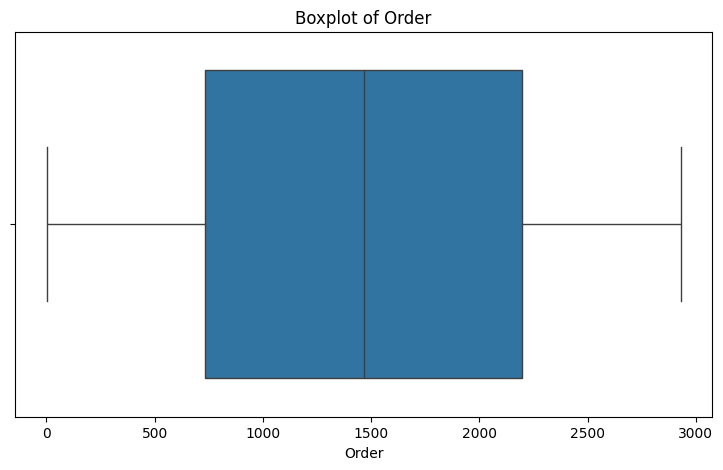

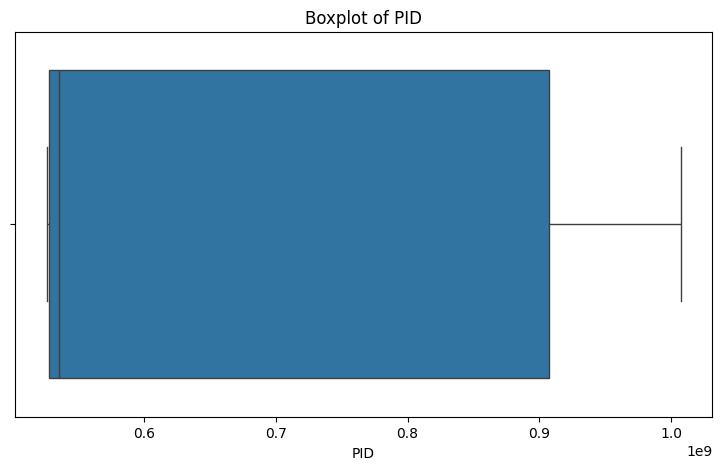

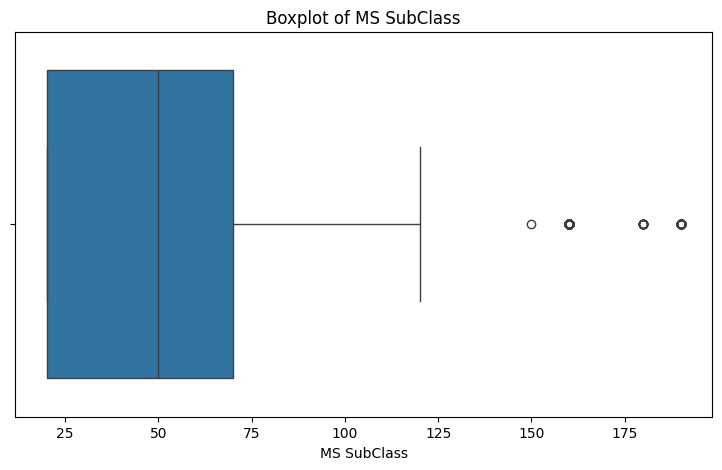

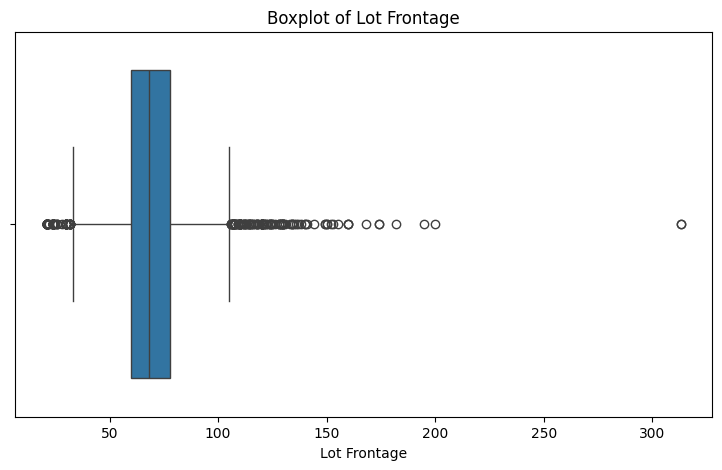

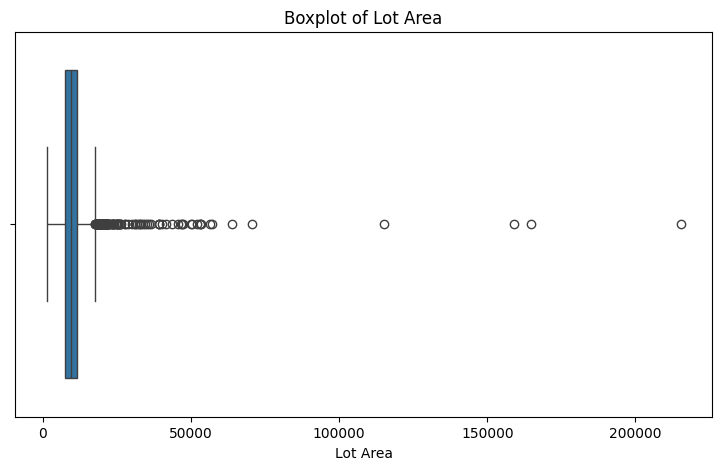

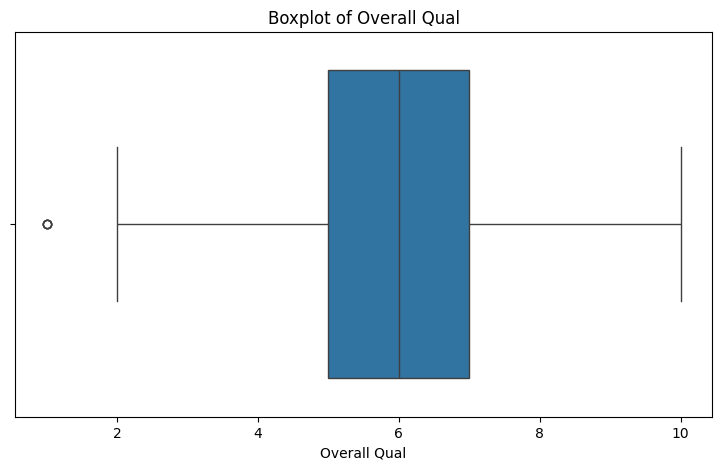

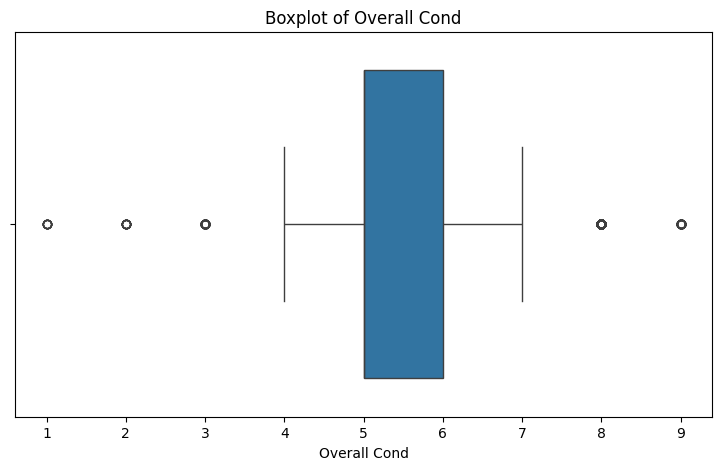

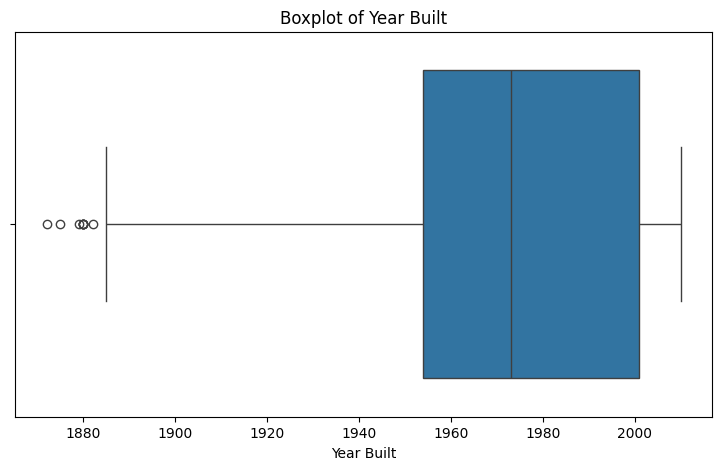

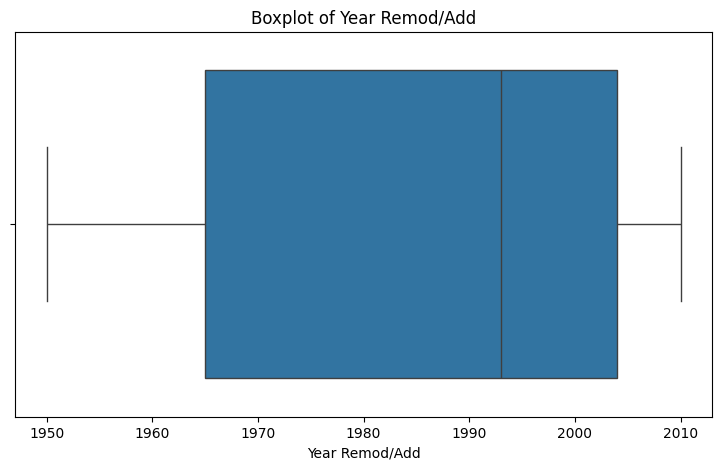

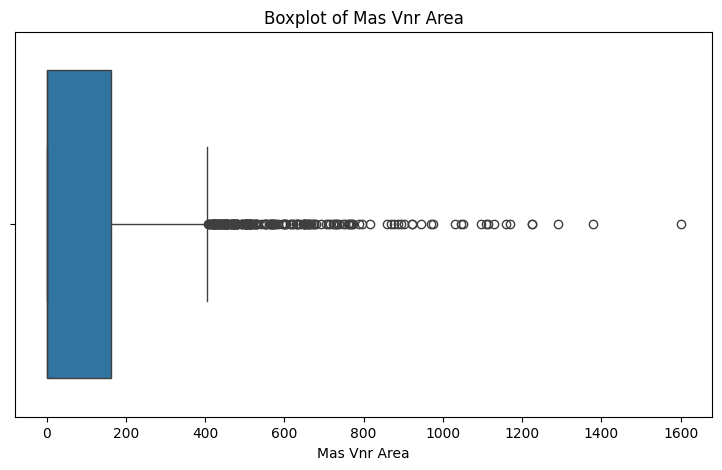

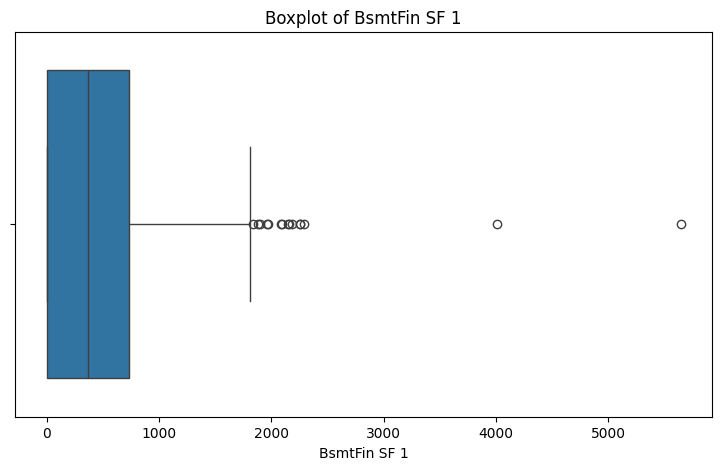

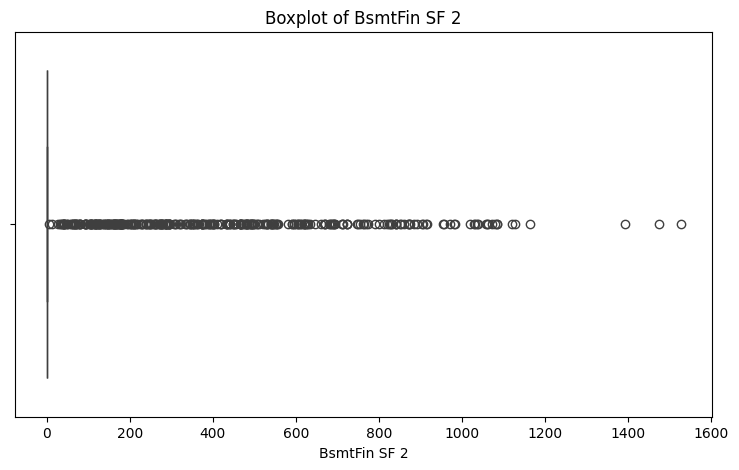

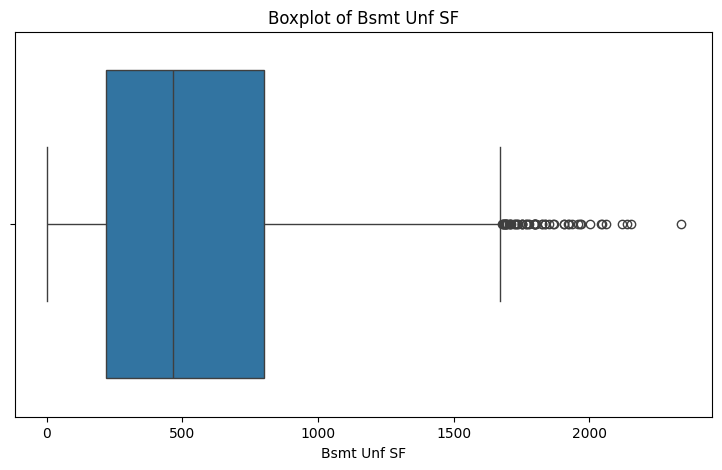

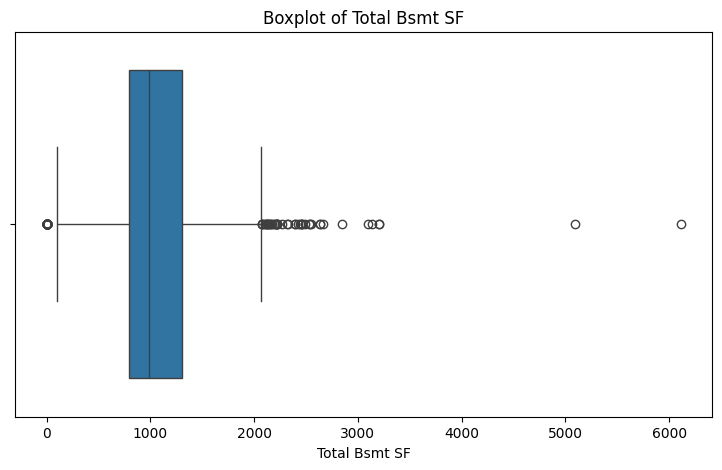

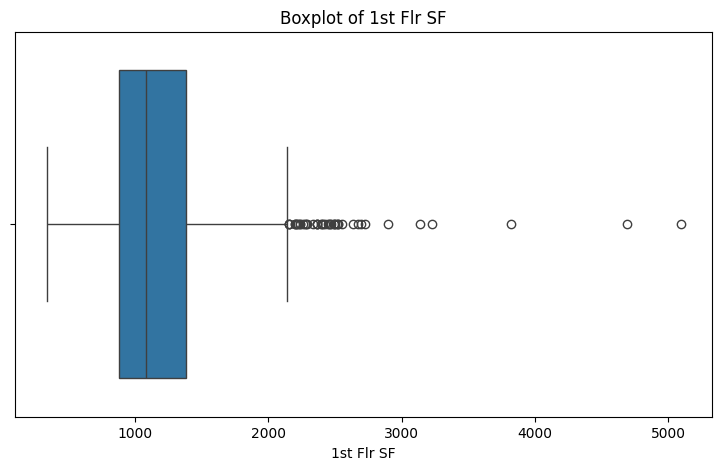

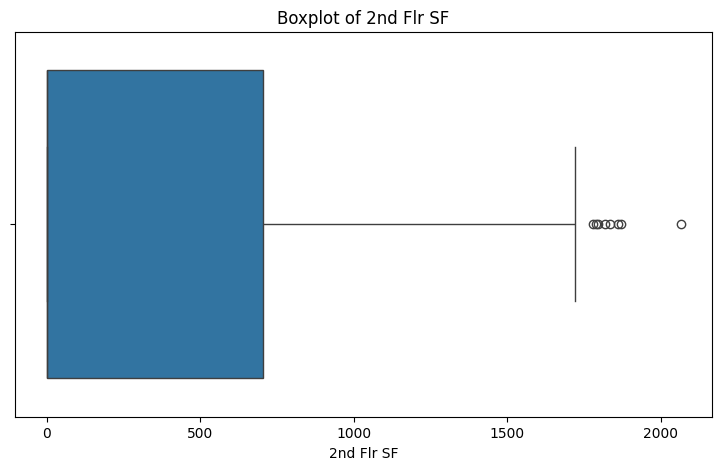

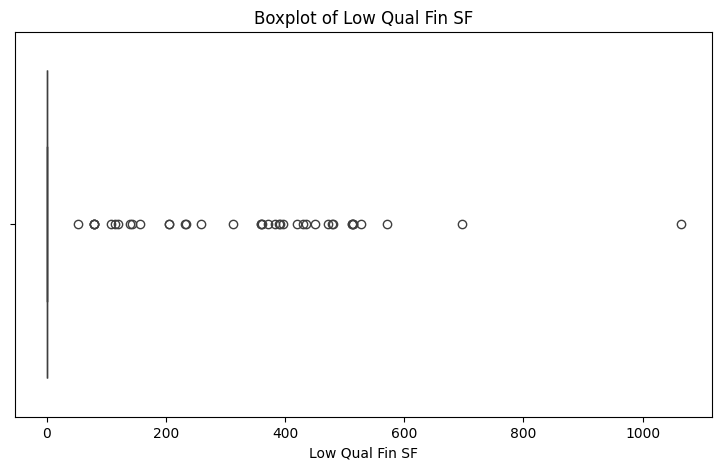

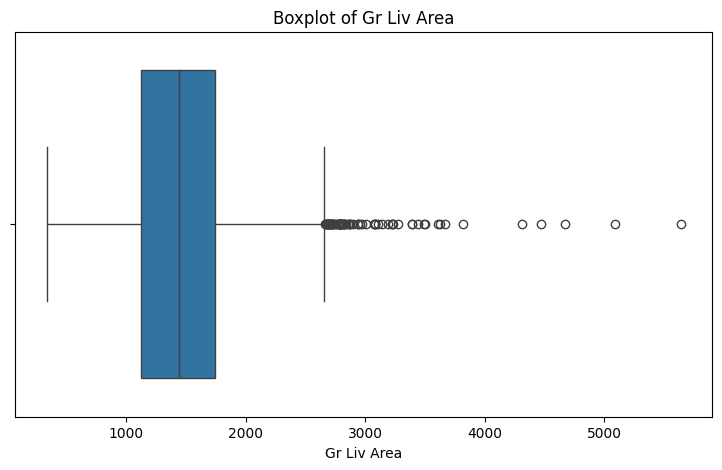

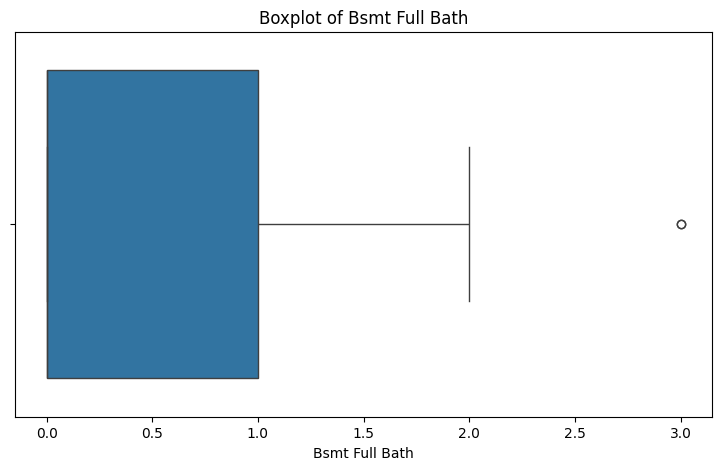

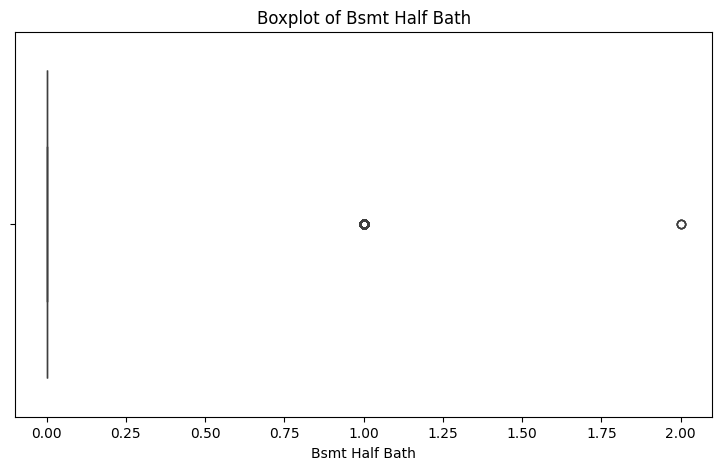

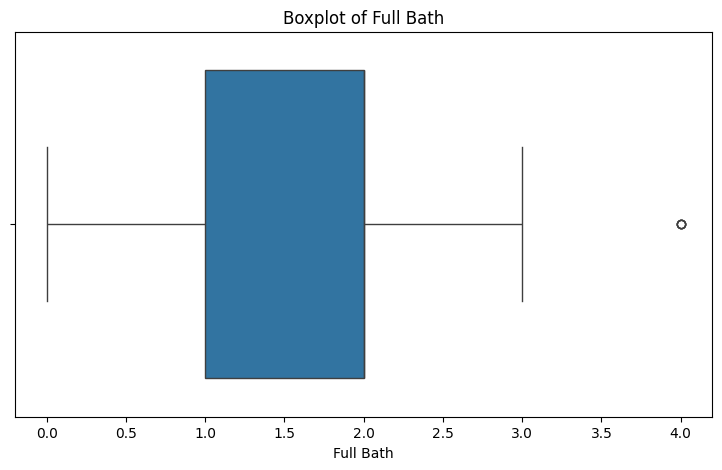

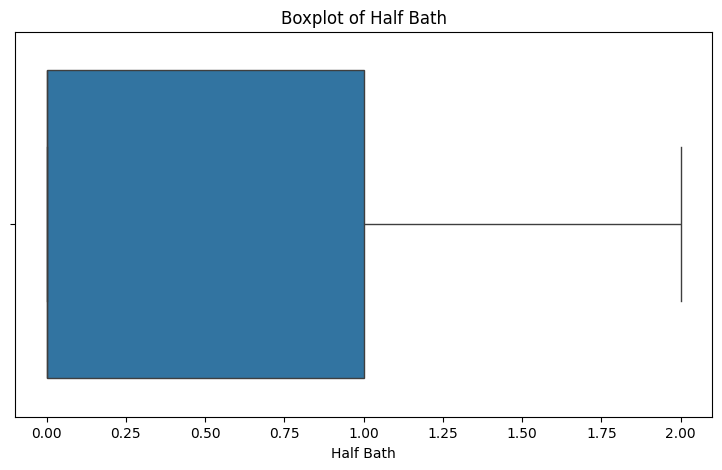

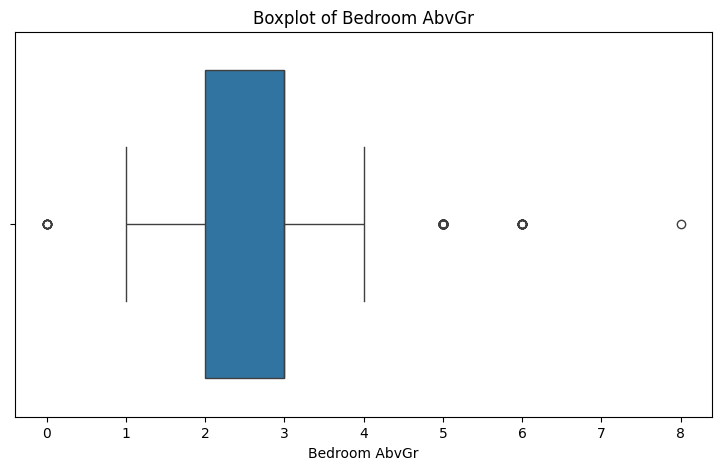

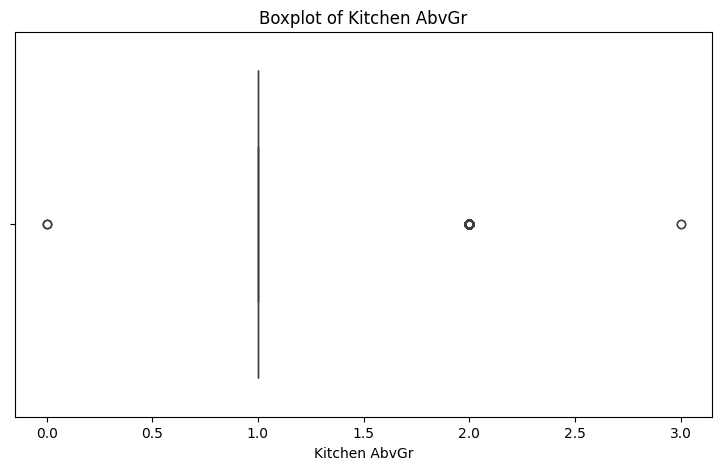

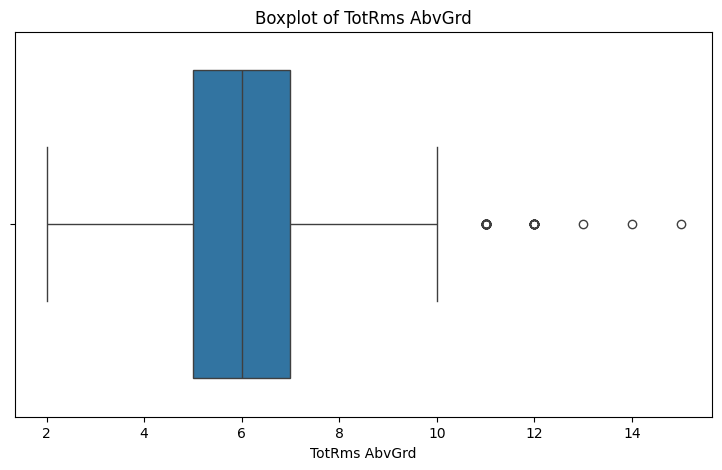

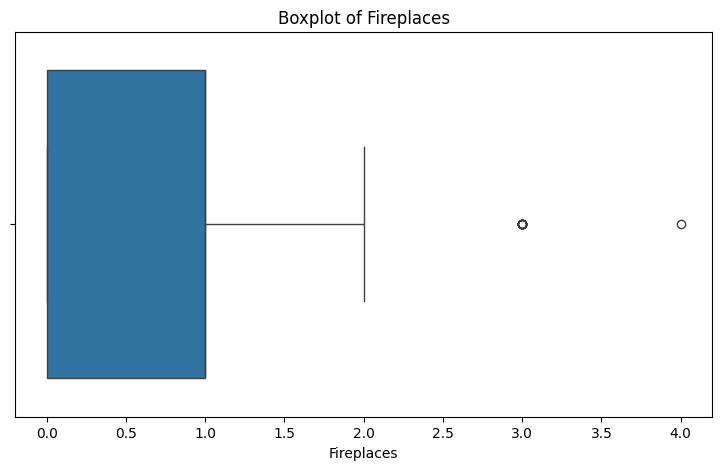

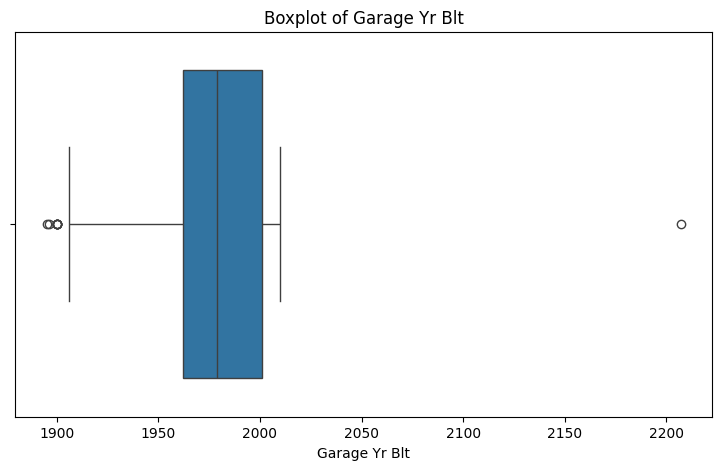

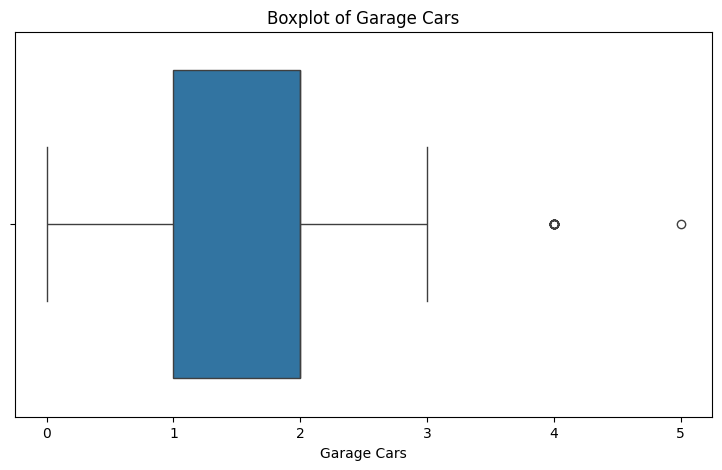

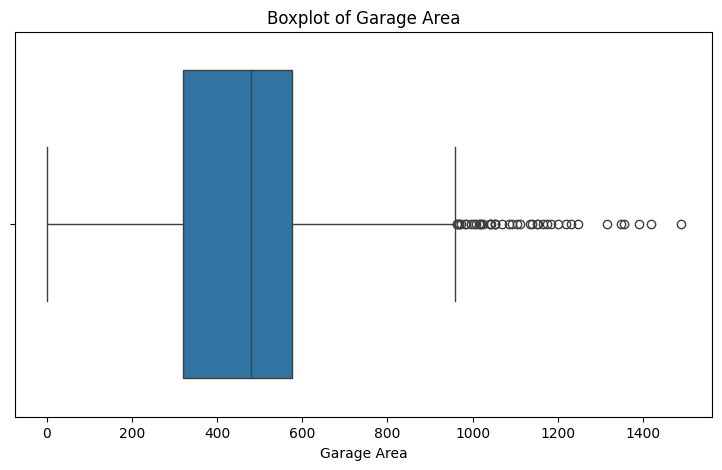

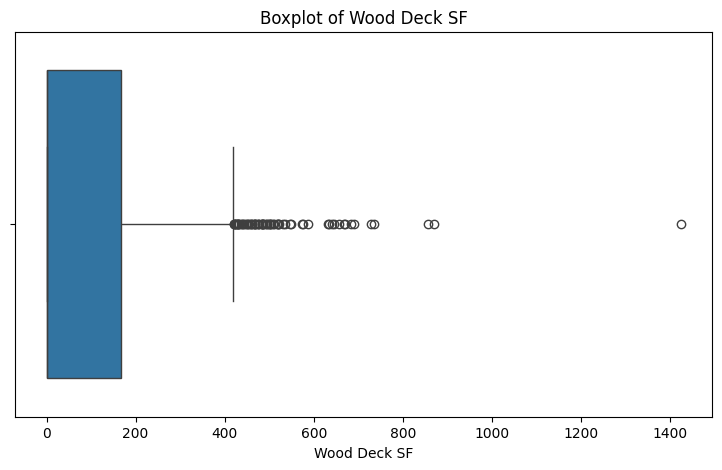

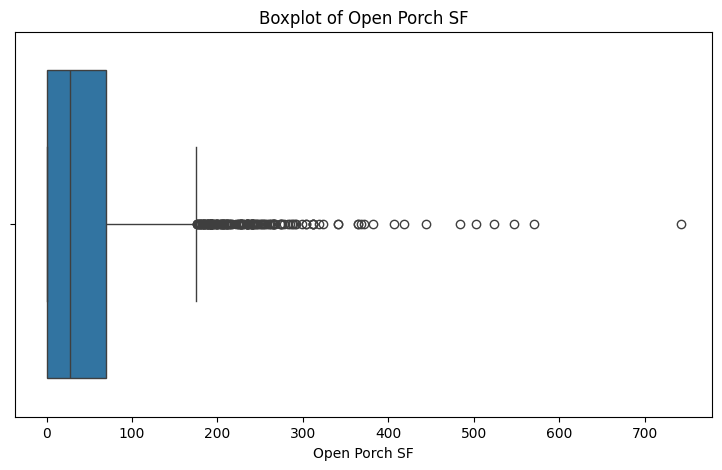

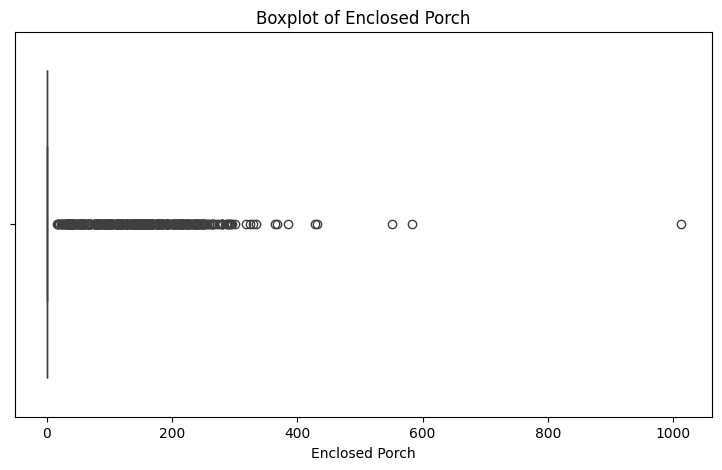

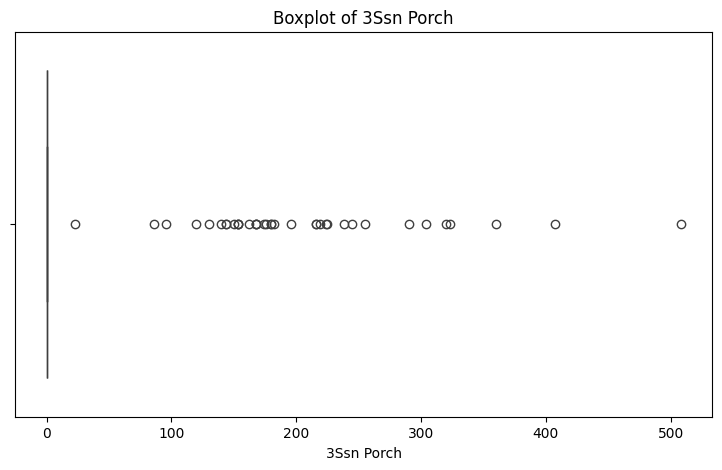

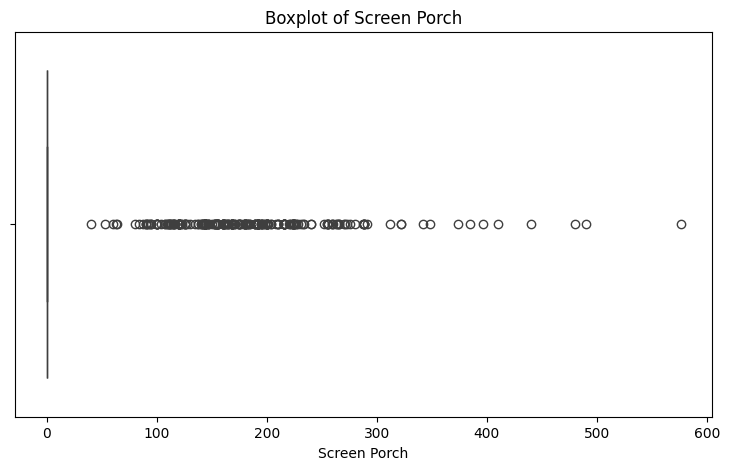

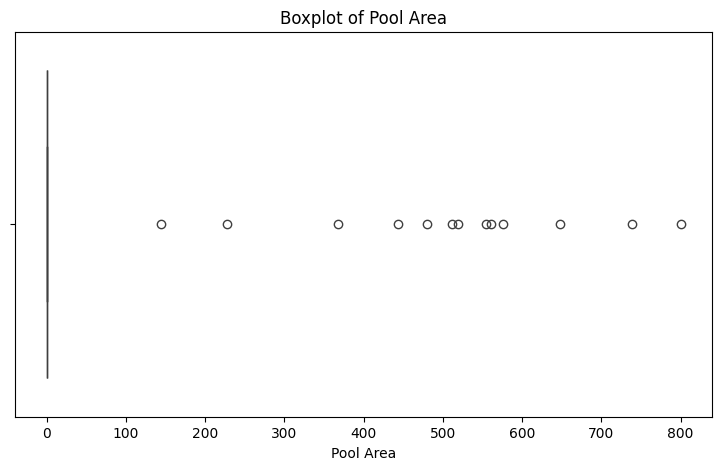

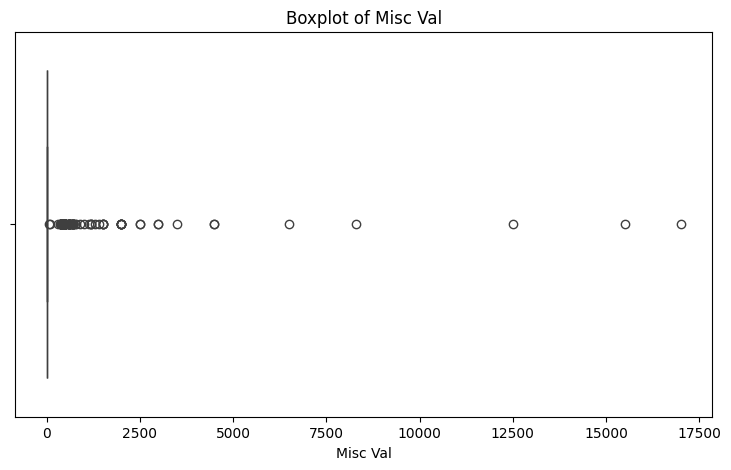

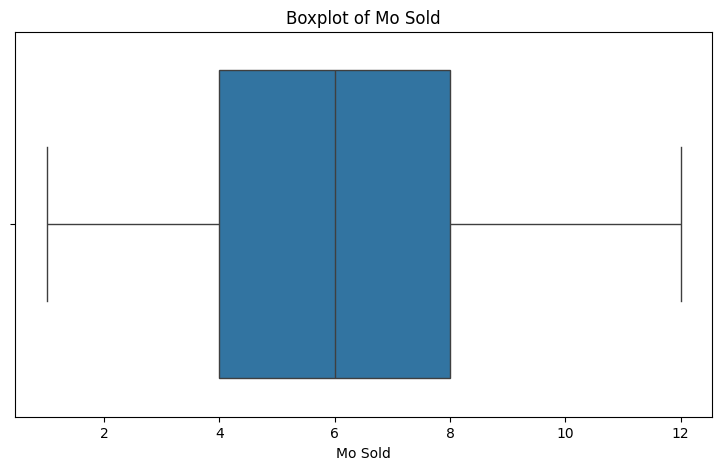

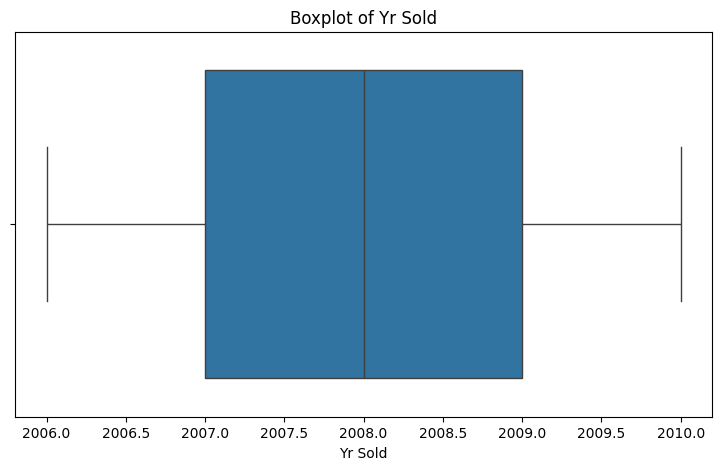

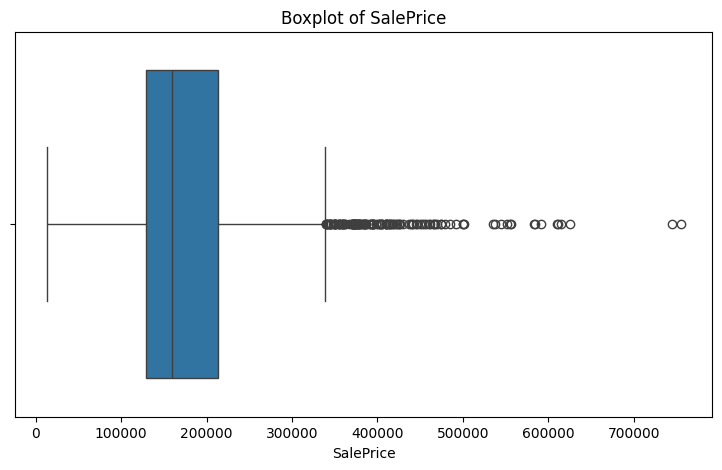

In [10]:
for feature in numeric_features:
    plt.figure(figsize=(9, 5))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

Keputusan: Menghapus data outlier dengan asumsi bahwa outlier yang terjadi merupakan human error dan tidak ada pengaruh yang besar pada analisis.

Keputusan: Menggunakan metode IQR. 

In [11]:
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

In [12]:
# Filter dataframe untuk hanya menyimpan baris yang tidak mengandung outliers pada kolom numerik
condition = ~((df[numeric_features] < (Q1 - 1.5 * IQR)) | (df[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)
df_filtered_numeric = df.loc[condition, numeric_features]
 
# Menggabungkan kembali dengan kolom kategorikal
categorical_features = df.select_dtypes(include=['object', 'str']).columns
df = pd.concat([df_filtered_numeric, df.loc[condition, categorical_features]], axis=1)

Pengecekan:

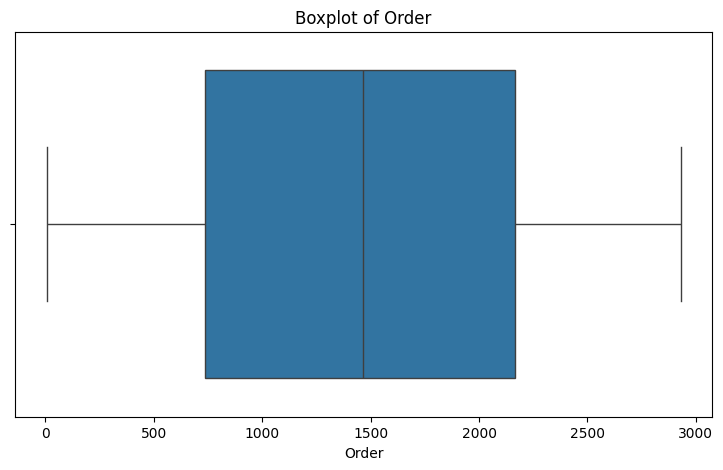

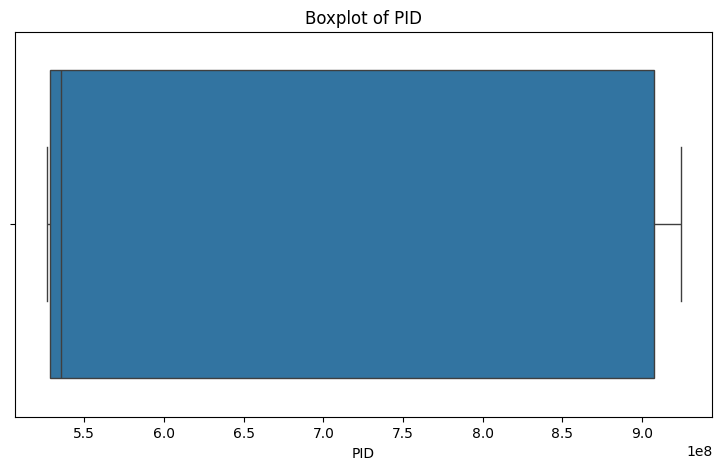

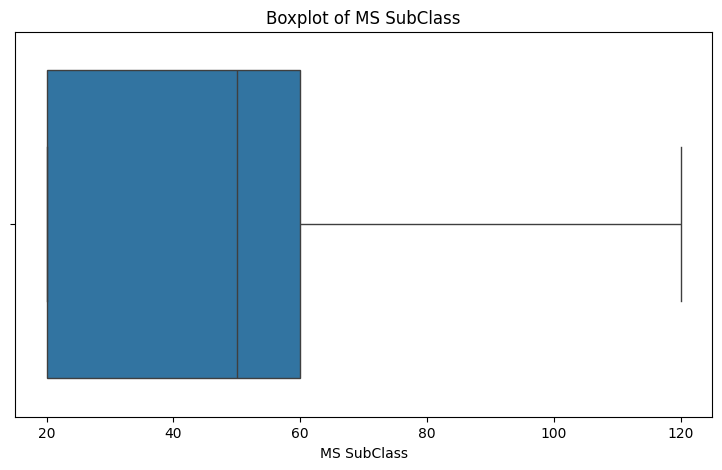

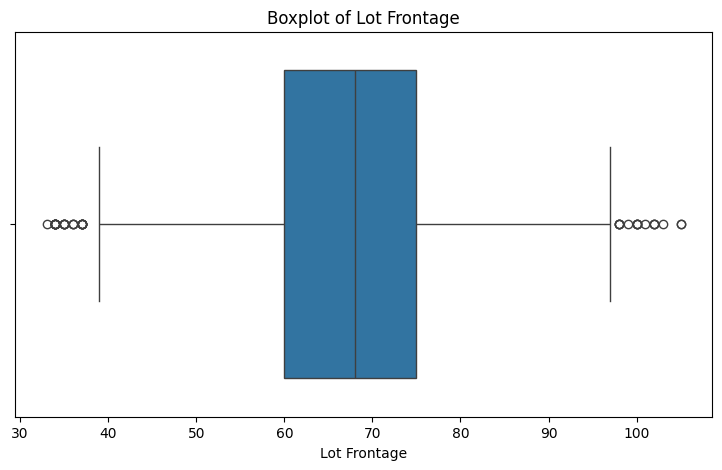

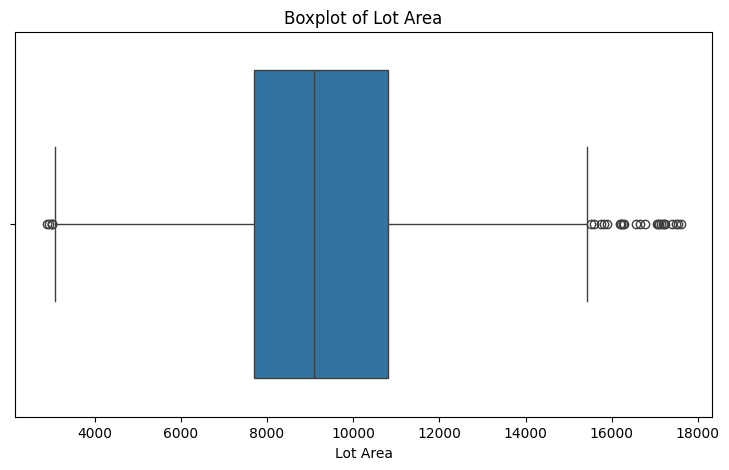

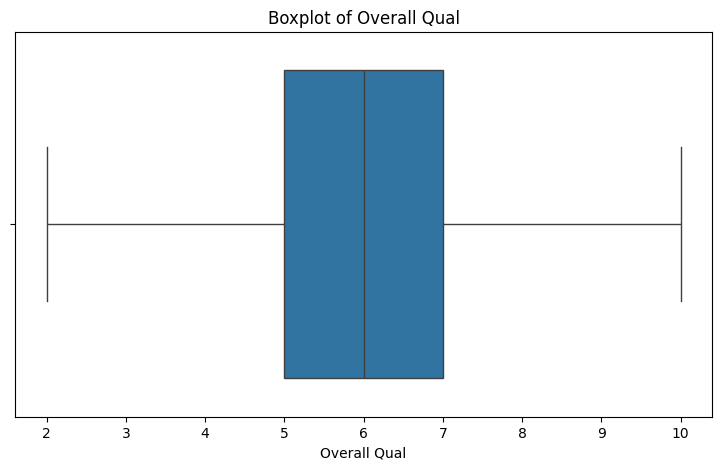

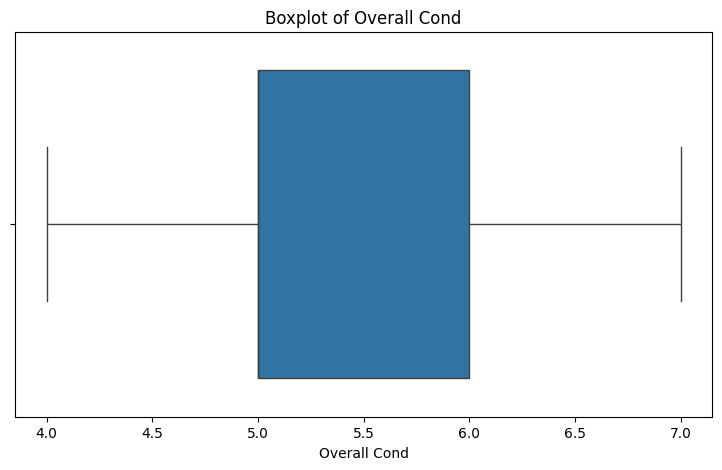

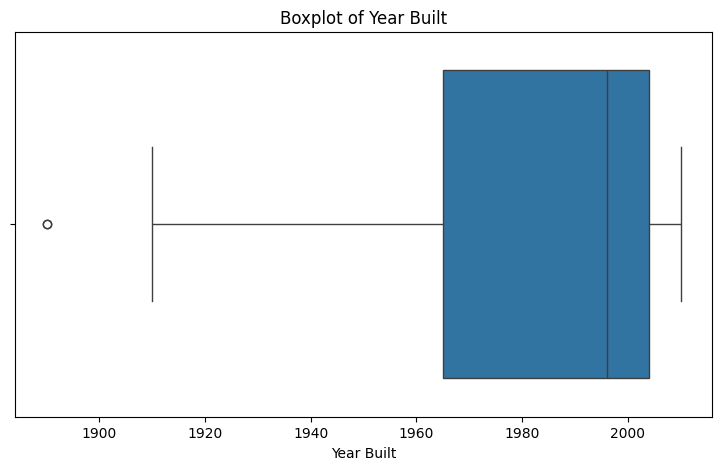

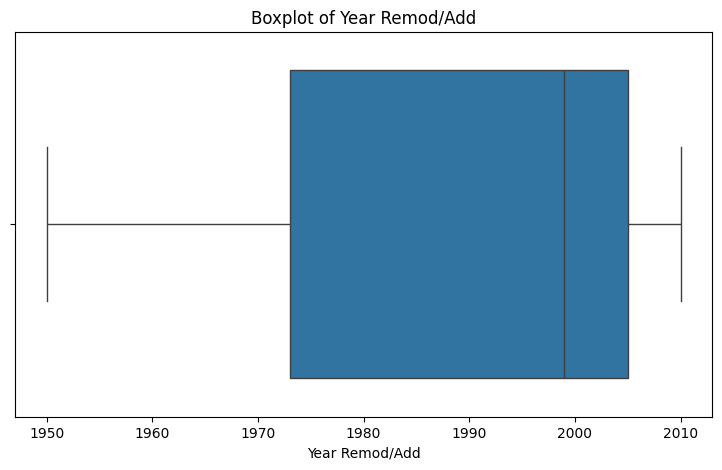

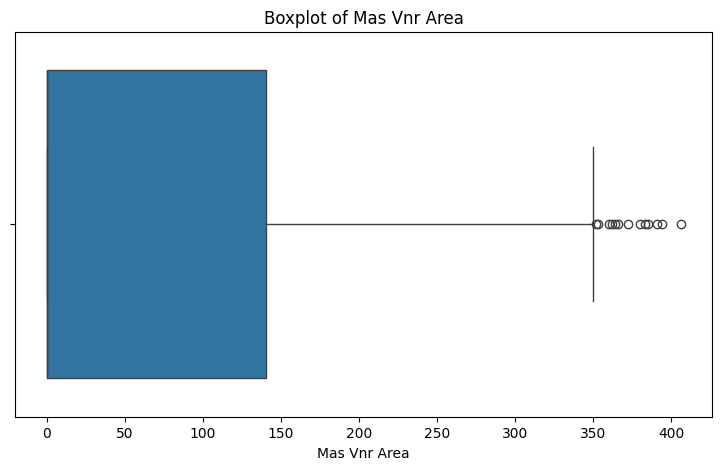

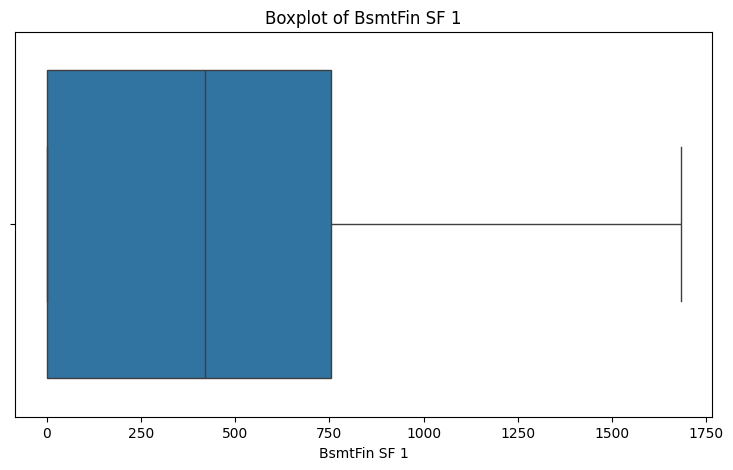

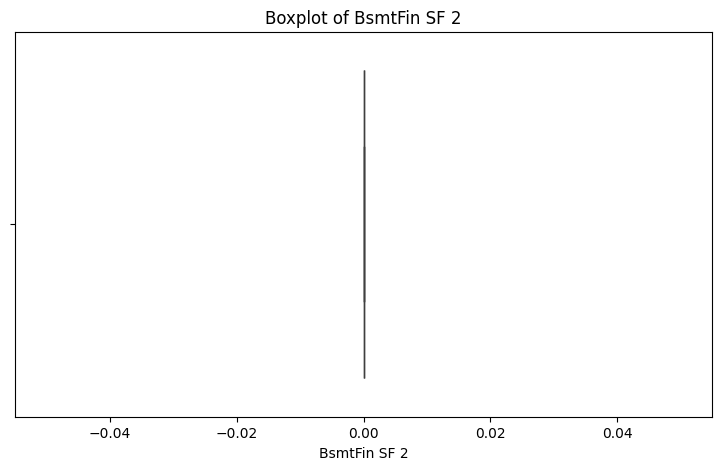

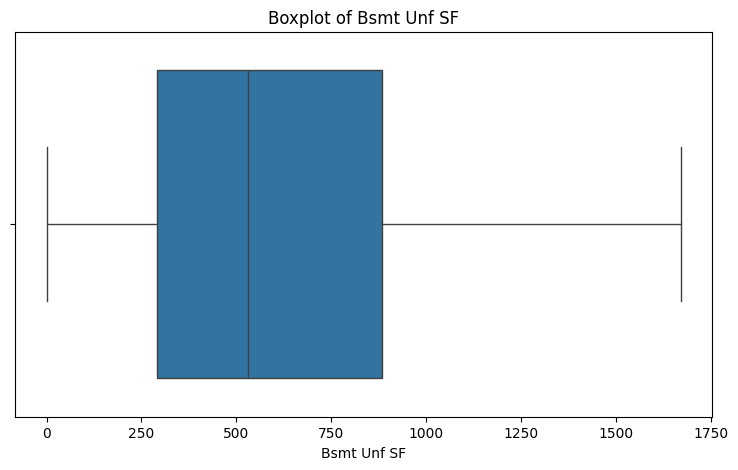

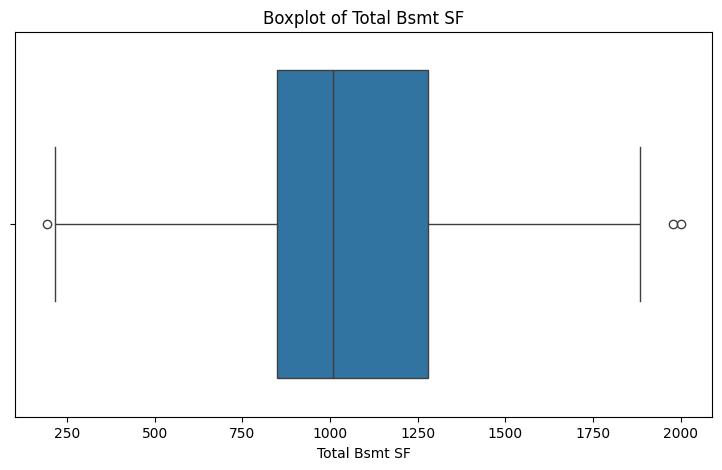

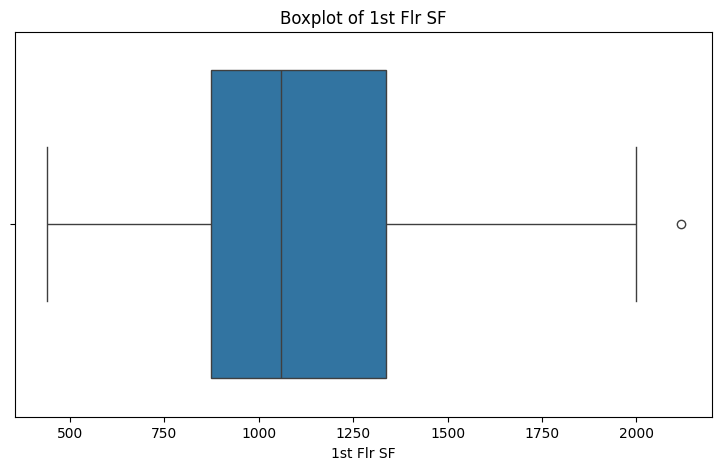

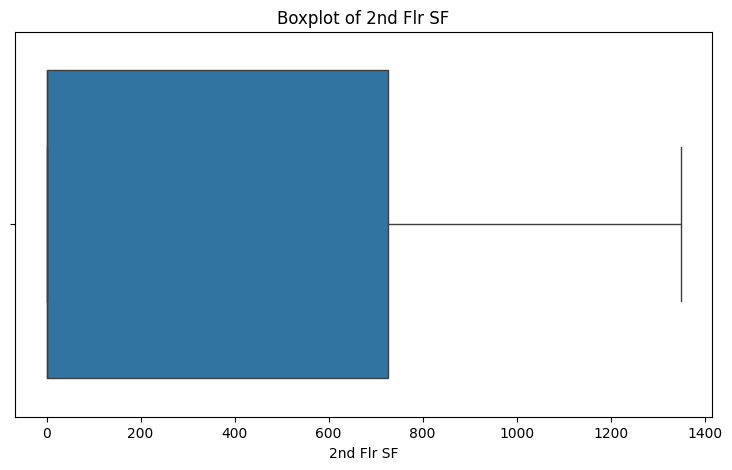

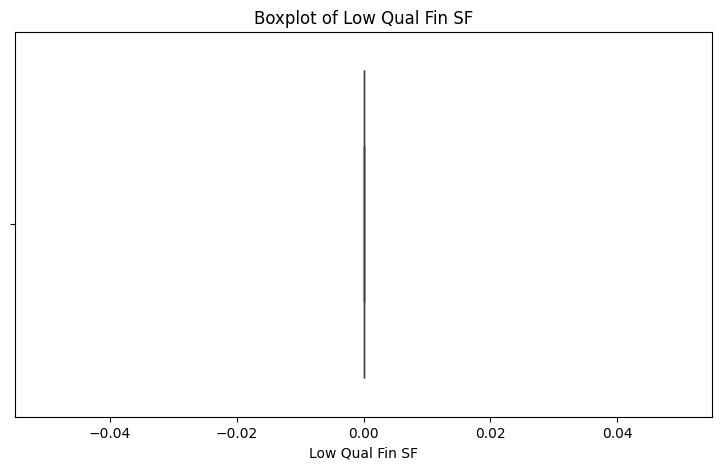

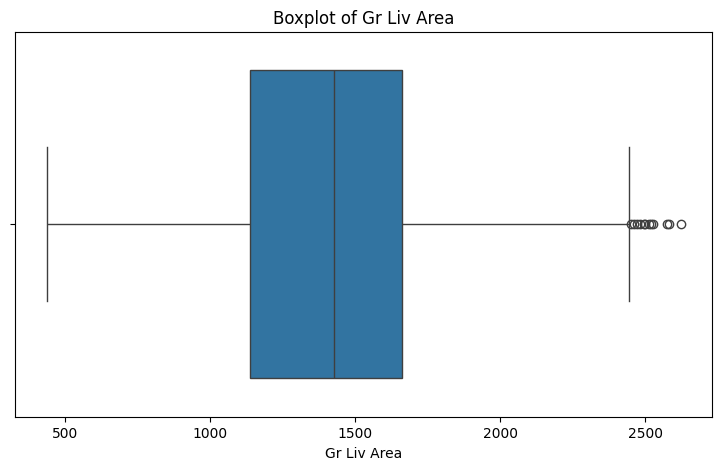

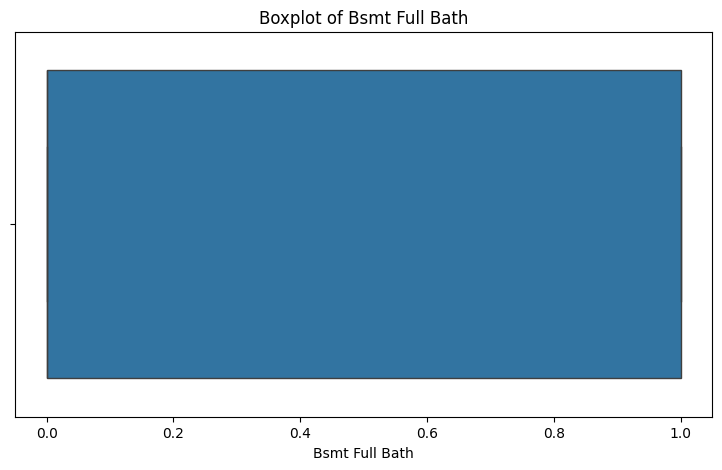

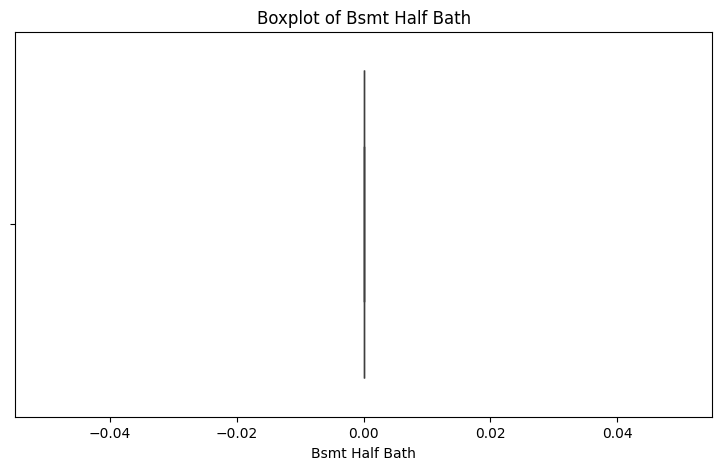

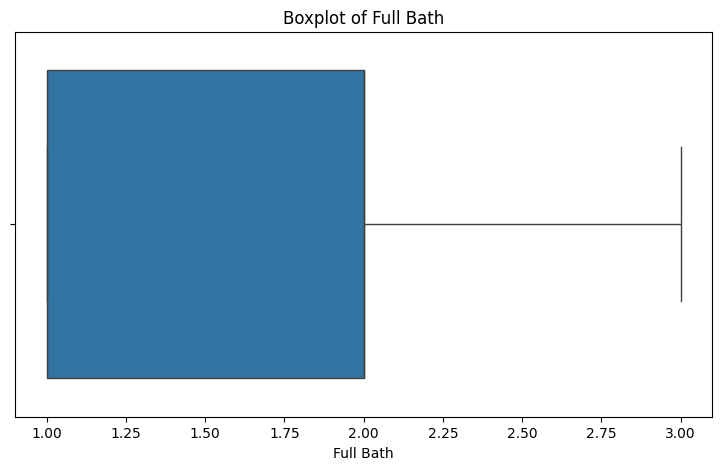

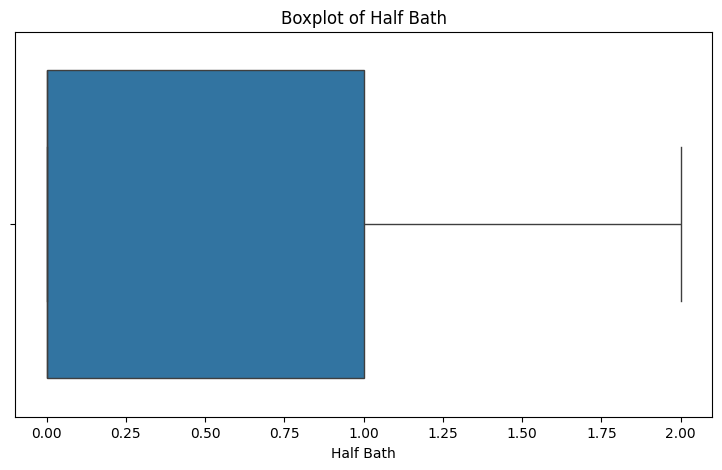

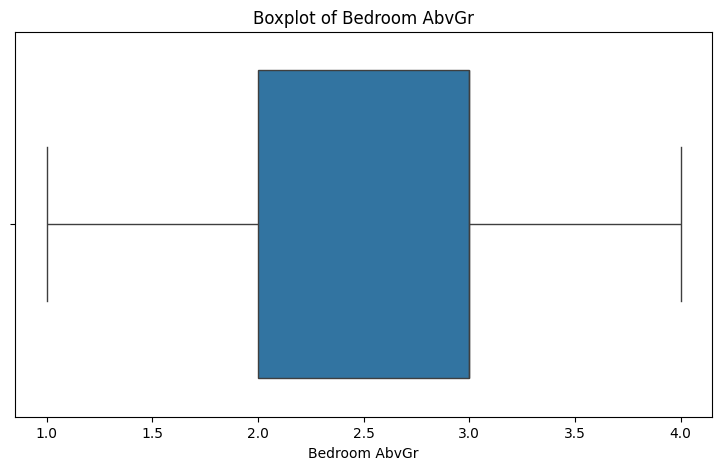

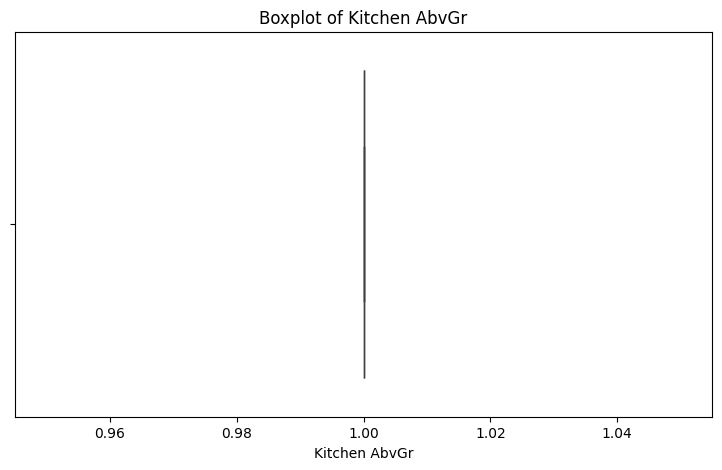

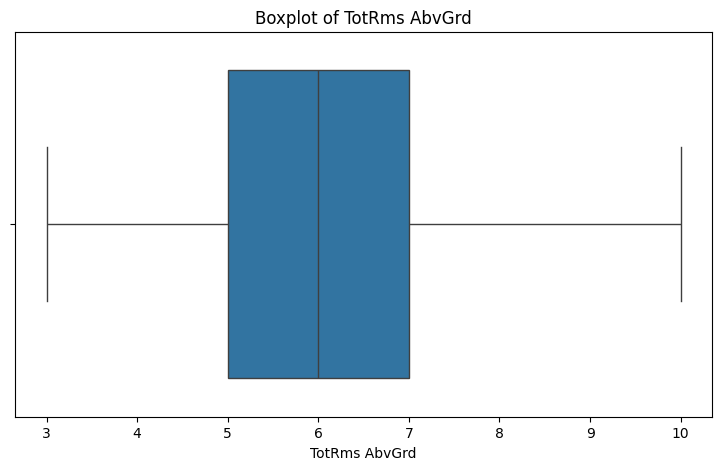

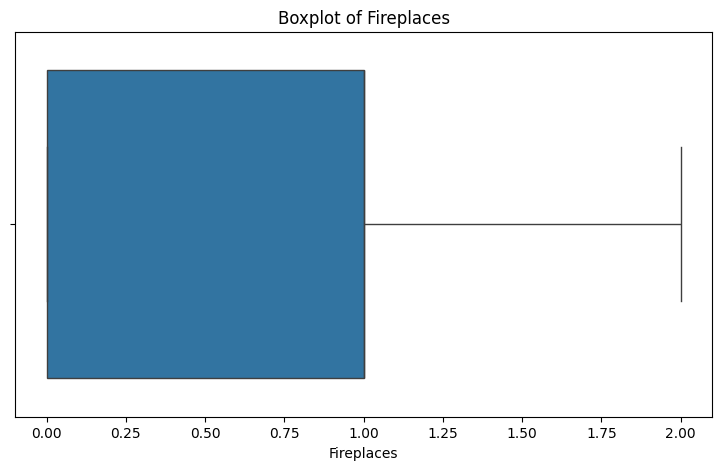

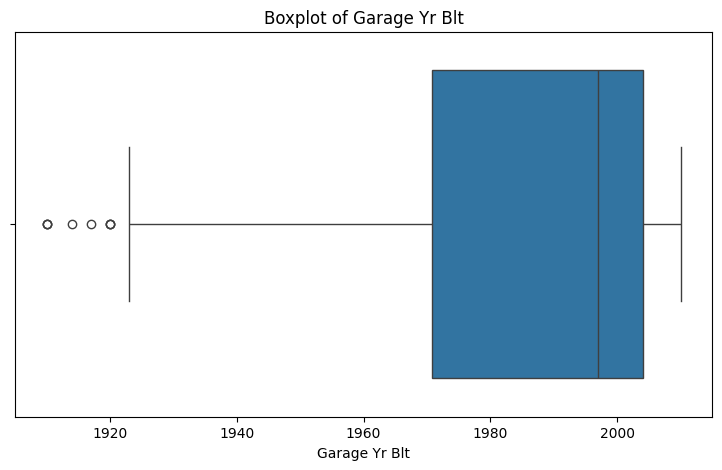

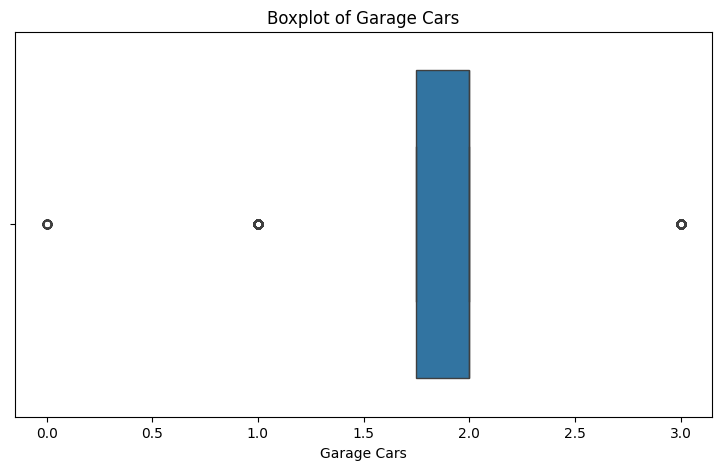

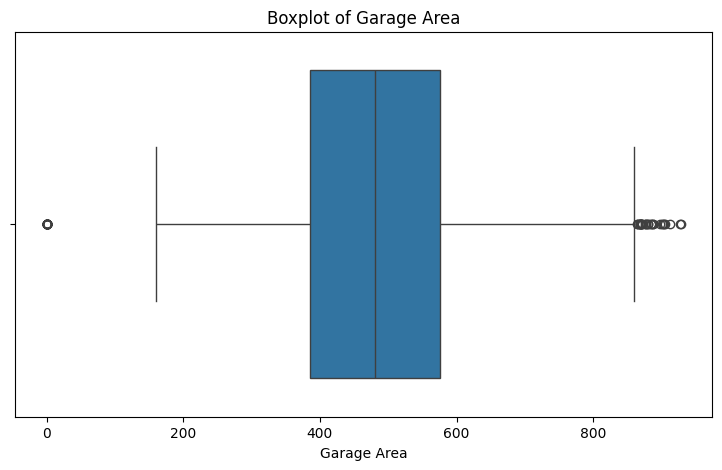

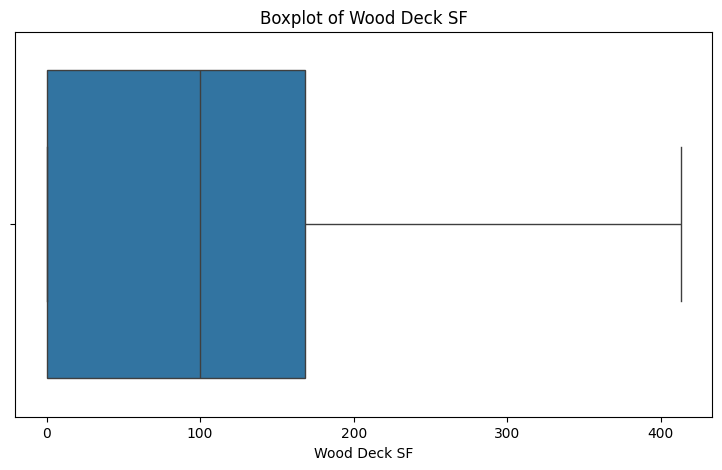

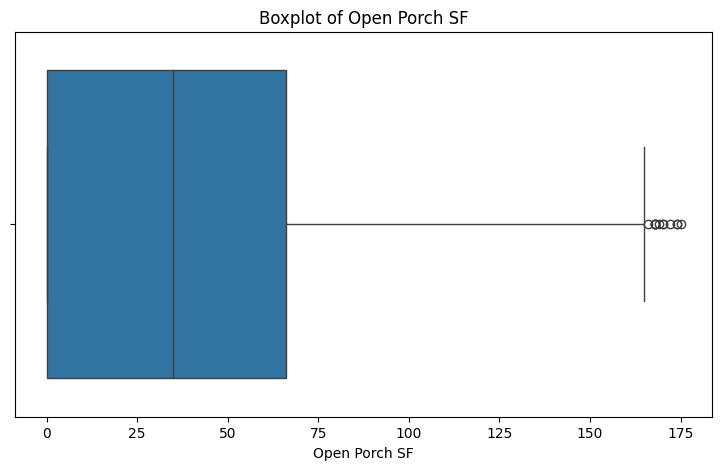

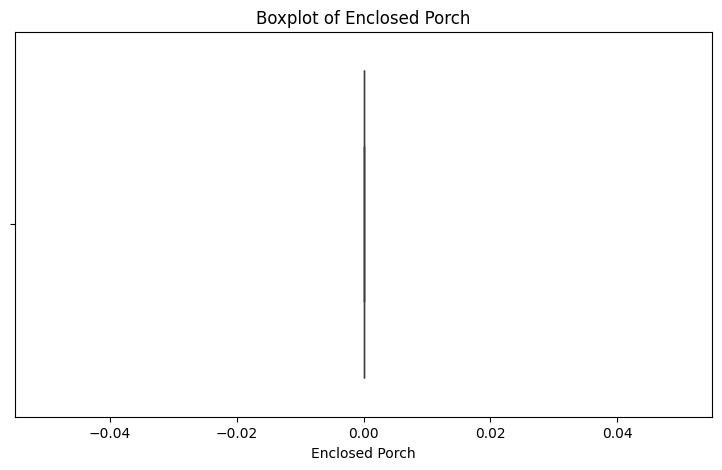

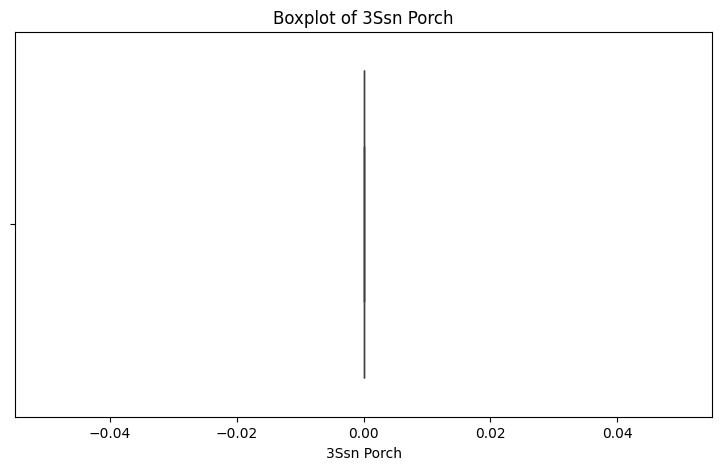

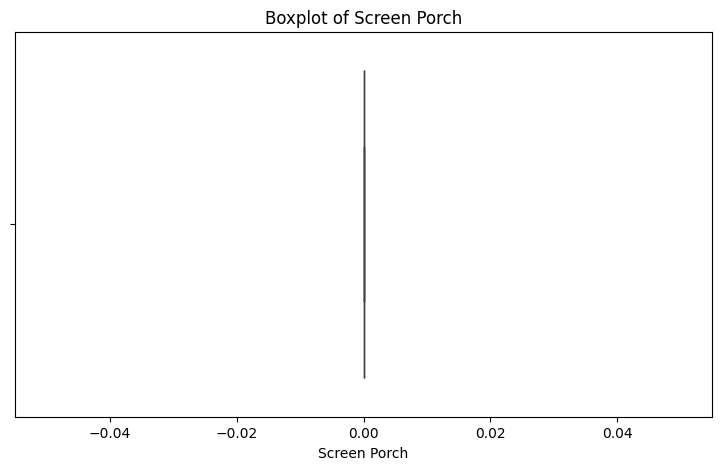

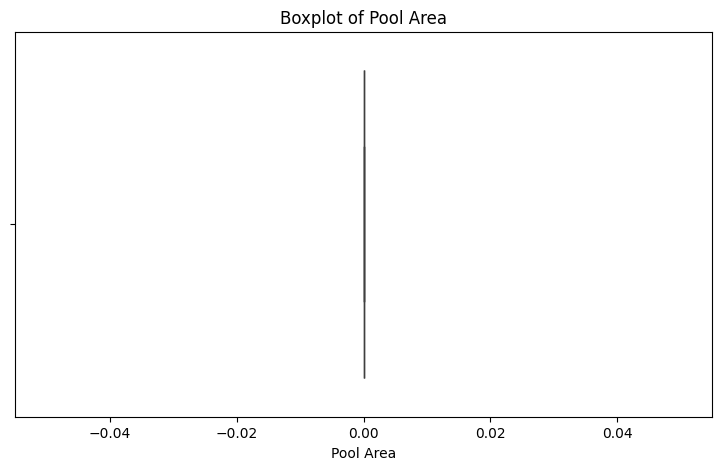

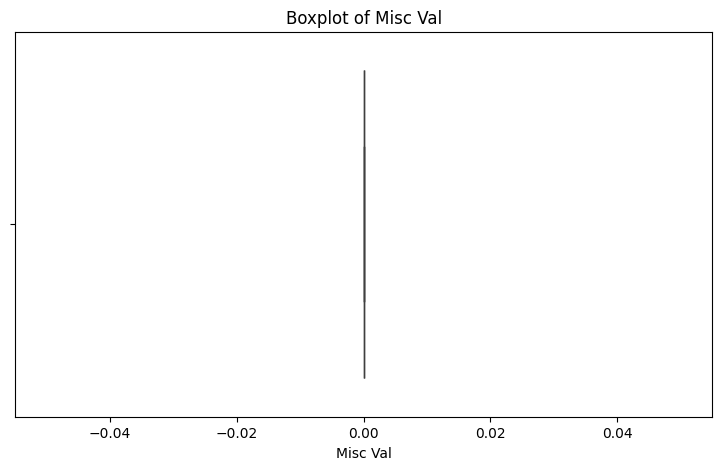

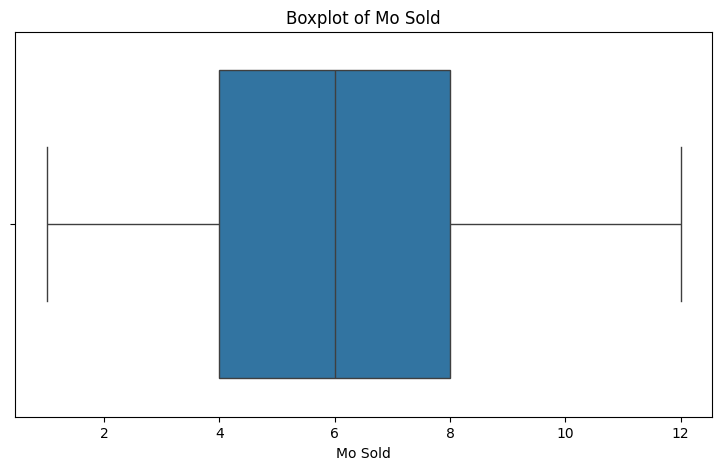

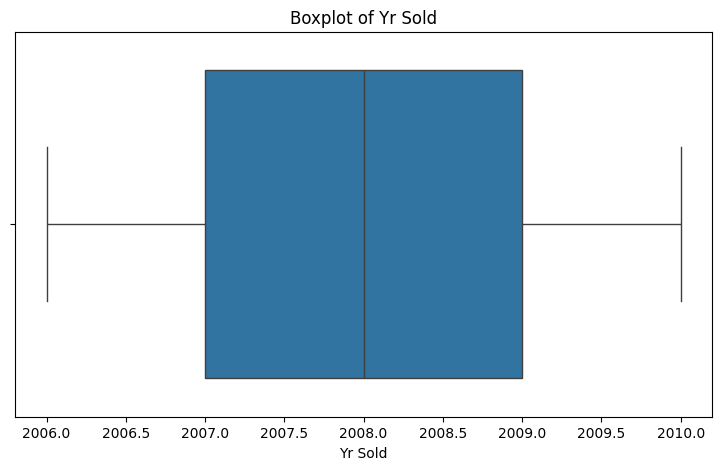

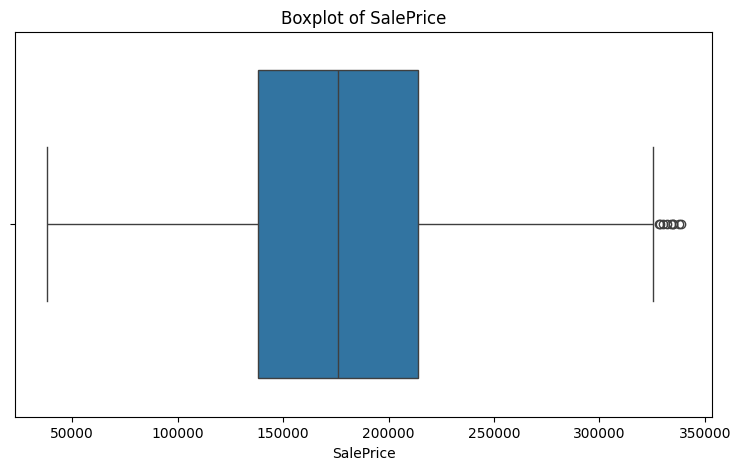

In [13]:
for feature in numeric_features:
    plt.figure(figsize=(9, 5))
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

### 2.4 Normalisasi dan Standarisasi Data

Keputusan: Kita akan melakukan standarisasi data.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

Text(0.5, 1.0, 'Histogram Sebelum Standardisasi')

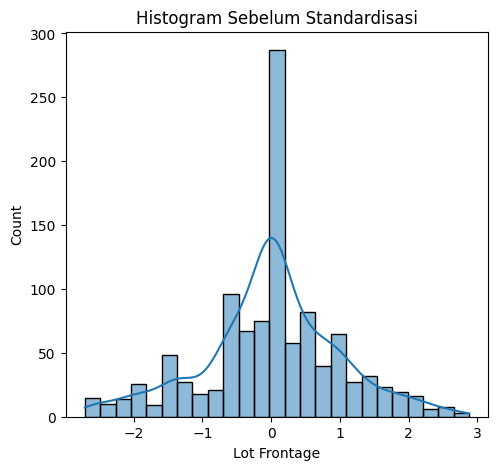

In [15]:
# Histogram Sebelum Standardisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[numeric_features[3]], kde=True)
plt.title("Histogram Sebelum Standardisasi")

Text(0.5, 1.0, 'Histogram Setelah Standardisasi')

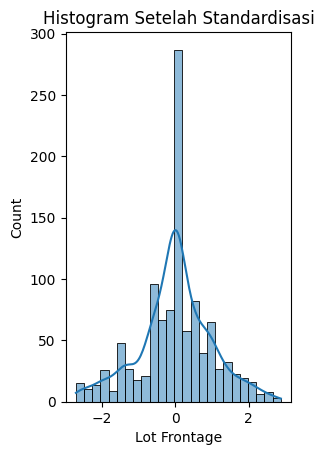

In [16]:
# Histogram Setelah Standardisasi
plt.subplot(1, 2, 2)
sns.histplot(df[numeric_features[3]], kde=True)
plt.title("Histogram Setelah Standardisasi")

### 2.5 Duplikasi Data

Keputusan: Menghapus data duplikat.

In [17]:
duplicates = df.duplicated().sum()

print(f"Jumlah baris duplikat: {duplicates}")

Jumlah baris duplikat: 0


Keterangan: TidaK dideteksi duplikasi data.

### 2.6 Mengonversi Tipe Data

Keterangan: Perhatikan lagi data kategorikal.

In [18]:
categorical_features = df.select_dtypes(include=['object', 'str']).columns
df[categorical_features].head()

,MS Zoning,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
4,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,TA,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
5,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,Gd,Typ,Gd,Attchd,Fin,TA,TA,Y,WD,Normal
8,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
9,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,Gd,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
10,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Gilbert,Norm,Norm,...,TA,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal


Keputusan: Kita akan menggunakan metode one hot encoding dan label encoding karena data kategorikal yang ada pada dataset ini tidak memiliki urutan.

#### 2.6.1 One Hot Encoding

In [19]:
df_one_hot = pd.get_dummies(df, columns=categorical_features)
df_one_hot.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
4,-1.733960,-0.901060,0.340641,0.473342,1.694238,-1.003022,-0.53115,0.531056,0.437228,-0.693366,...,False,False,False,False,True,False,False,False,True,False
5,-1.732765,-0.901060,0.340641,0.784066,0.274332,-0.215036,0.89746,0.570522,0.437228,-0.498554,...,False,False,False,False,True,False,False,False,True,False
8,-1.729182,-0.900842,2.257241,-2.245492,-1.417244,1.360935,-0.53115,0.452124,0.335847,-0.693366,...,False,False,False,False,True,False,False,False,True,False
9,-1.727987,-0.900756,0.340641,-0.614192,-0.639097,0.572949,-0.53115,0.609988,0.487919,-0.693366,...,False,False,False,False,True,False,False,False,True,False
10,-1.726793,-0.900751,0.340641,0.551023,0.282441,-0.215036,-0.53115,0.373192,0.234467,-0.693366,...,False,False,False,False,True,False,False,False,True,False


#### 2.6.2 Label Encoding

In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_lencoder = pd.DataFrame(df)


for column in categorical_features:
    df_lencoder[column] = label_encoder.fit_transform(df[column])

df_lencoder.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
4,-1.733960,-0.901060,0.340641,0.473342,1.694238,-1.003022,-0.53115,0.531056,0.437228,-0.693366,...,3,5,4,1,0,3,4,2,8,3
5,-1.732765,-0.901060,0.340641,0.784066,0.274332,-0.215036,0.89746,0.570522,0.437228,-0.498554,...,2,5,2,1,0,3,4,2,8,3
8,-1.729182,-0.900842,2.257241,-2.245492,-1.417244,1.360935,-0.53115,0.452124,0.335847,-0.693366,...,2,5,4,1,1,3,4,2,8,3
9,-1.727987,-0.900756,0.340641,-0.614192,-0.639097,0.572949,-0.53115,0.609988,0.487919,-0.693366,...,2,5,4,1,0,3,4,2,8,3
10,-1.726793,-0.900751,0.340641,0.551023,0.282441,-0.215036,-0.53115,0.373192,0.234467,-0.693366,...,3,5,4,1,0,3,4,2,8,3


## 3. Exploratory dan Explanatory Data Analysis
Tujuan: Memahami struktur, karakteristik, dan pola dalam data.

Keputusan: Kita akan menggunakan data hasil label encoder.

In [21]:
df_lencoder.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
4,-1.733960,-0.901060,0.340641,0.473342,1.694238,-1.003022,-0.53115,0.531056,0.437228,-0.693366,...,3,5,4,1,0,3,4,2,8,3
5,-1.732765,-0.901060,0.340641,0.784066,0.274332,-0.215036,0.89746,0.570522,0.437228,-0.498554,...,2,5,2,1,0,3,4,2,8,3
8,-1.729182,-0.900842,2.257241,-2.245492,-1.417244,1.360935,-0.53115,0.452124,0.335847,-0.693366,...,2,5,4,1,1,3,4,2,8,3
9,-1.727987,-0.900756,0.340641,-0.614192,-0.639097,0.572949,-0.53115,0.609988,0.487919,-0.693366,...,2,5,4,1,0,3,4,2,8,3
10,-1.726793,-0.900751,0.340641,0.551023,0.282441,-0.215036,-0.53115,0.373192,0.234467,-0.693366,...,3,5,4,1,0,3,4,2,8,3


### 3.1 Pemeriksaan Kembali Data

In [22]:
# Menghitung jumlah dan persentase missing values untuk setiap kolom
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage}).sort_values(by='Missing Values', ascending=False)

missing_data[missing_data['Missing Values'] > 0]

,Missing Values,Percentage


Keterangan: Tidak ada missing value.

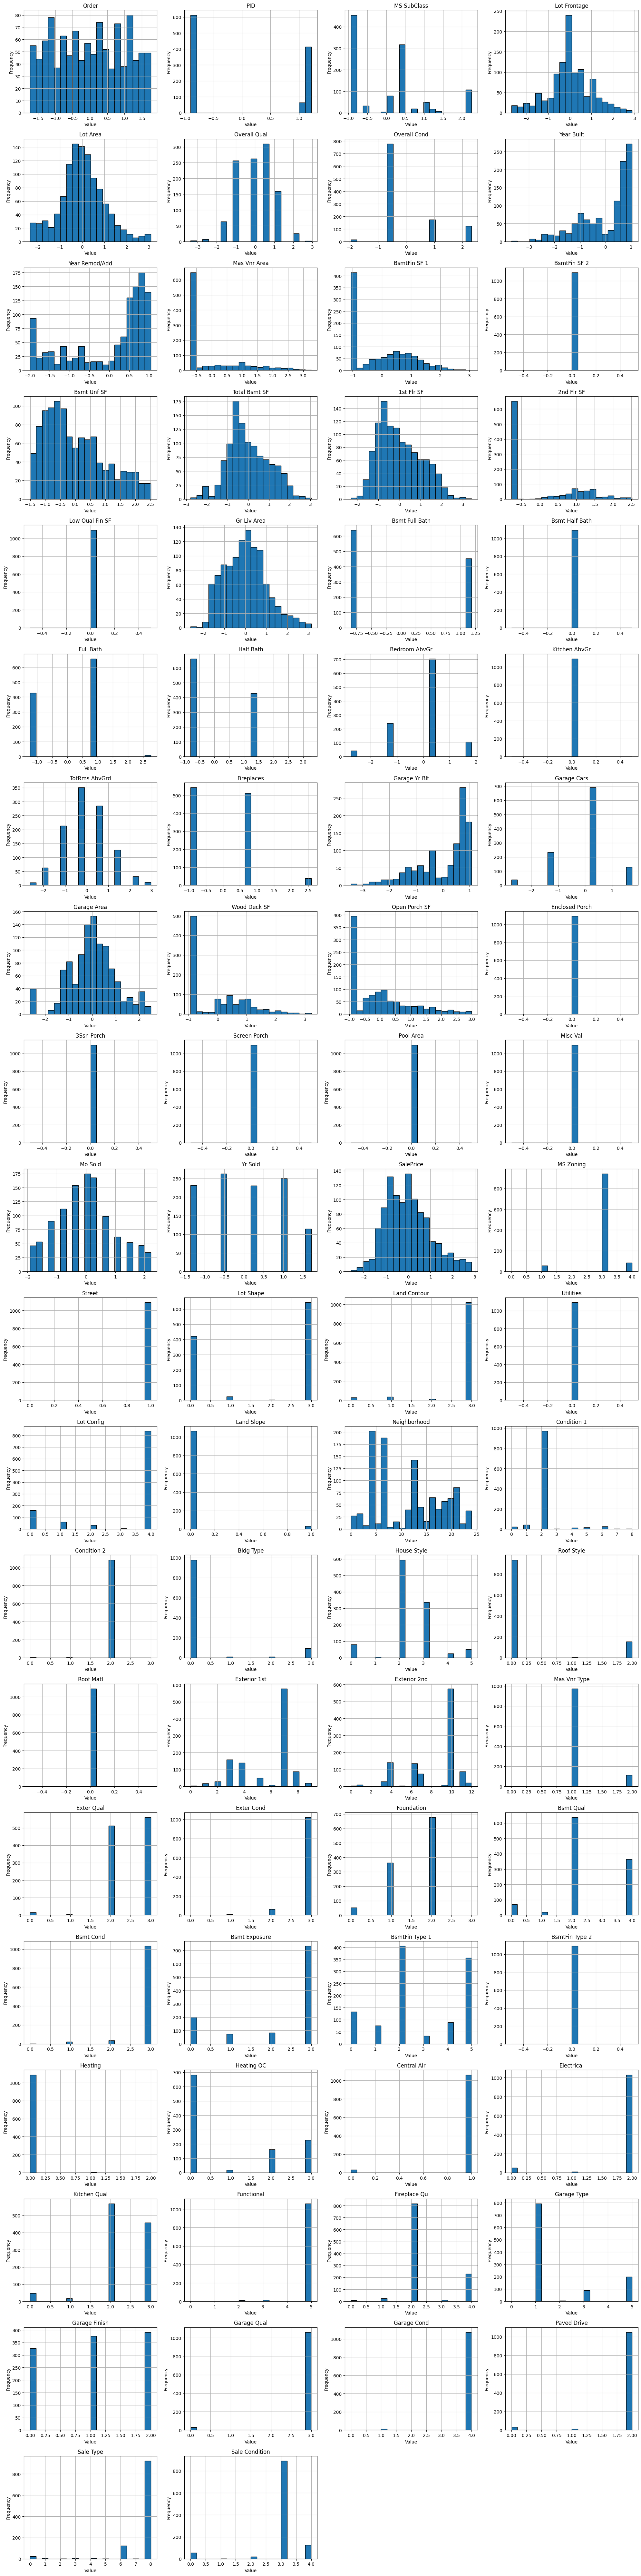

In [23]:
# Menghitung jumlah variabel
num_vars = df_lencoder.shape[1]
 
# Menentukan jumlah baris dan kolom untuk grid subplot
n_cols = 4 
n_rows = -(-num_vars // n_cols)
 
# Membuat subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
 
# Flatten axes array untuk memudahkan iterasi
axes = axes.flatten()
 
# Plot setiap variabel
for i, column in enumerate(df_lencoder.columns):
    df_lencoder[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
 
# Menghapus subplot yang tidak terpakai (jika ada)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
 
# Menyesuaikan layout agar lebih rapi
plt.tight_layout()
plt.show()

### 3.2 Korelasi

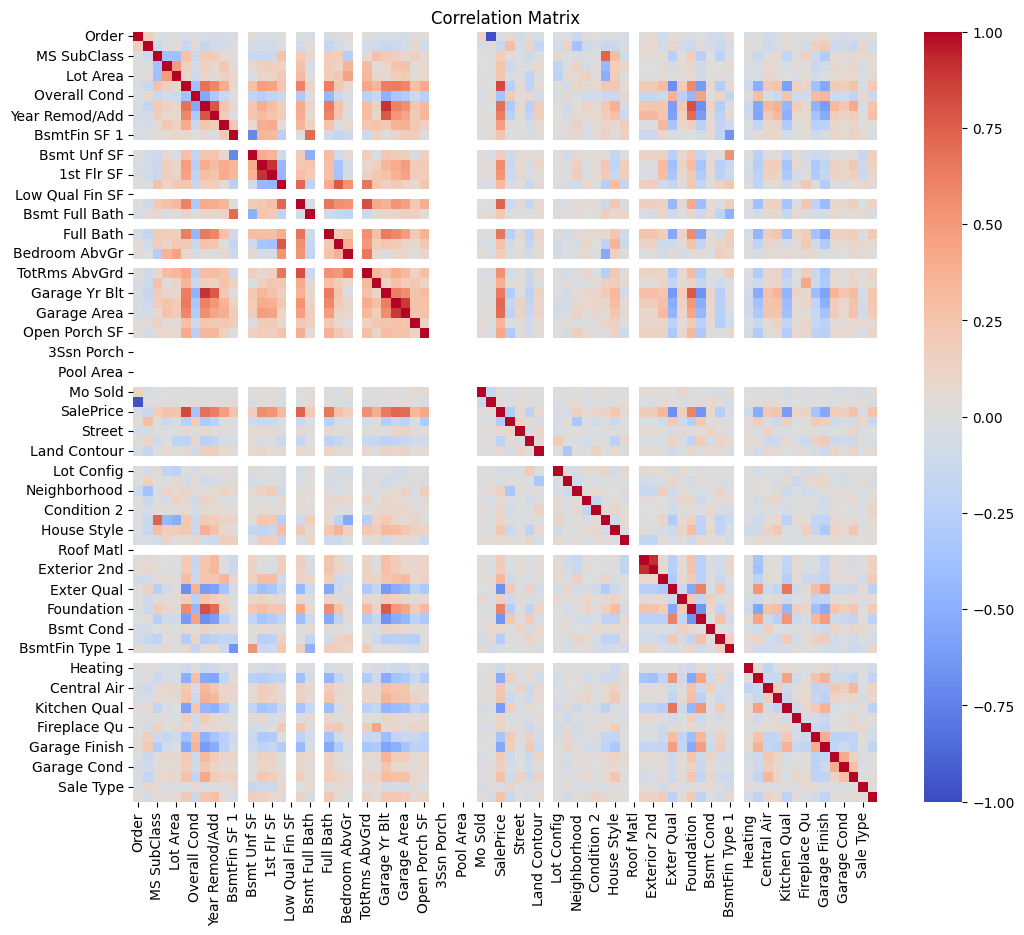

In [24]:
# Visualisasi korelasi antar variabel numerik
plt.figure(figsize=(12, 10))
correlation_matrix = df_lencoder.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

Keputusan : Analisis lagi korelasi semua variabel dengan sale price.

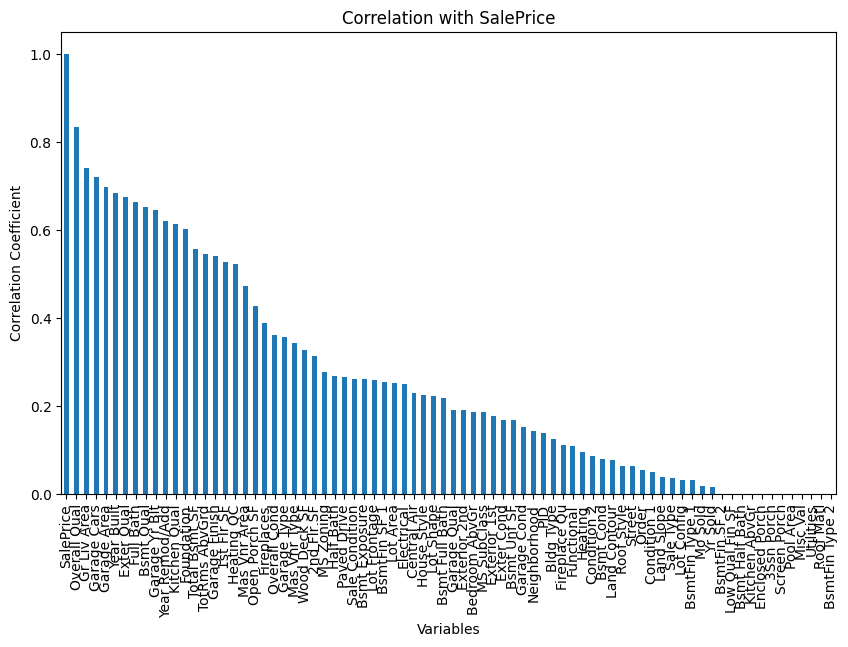

In [25]:
# Menghitung korelasi antara variabel target dan semua variabel lainnya
target_corr = df_lencoder.corr()['SalePrice']
 
# (Opsional) Mengurutkan hasil korelasi berdasarkan korelasi
target_corr_sorted = target_corr.abs().sort_values(ascending=False)
 
plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with SalePrice')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

Berdasarkan grafik koefisien korelasi terhadap nilai harga jual rumah (SalePrice), berikut adalah poin-poin kesimpulan utamanya:

* Korelasi Sempurna (1.0): Variabel SalePrice memiliki korelasi bernilai 1.0 karena berkorelasi dengan dirinya sendiri.
* Faktor Penentu Utama (> 0.7): Kualitas keseluruhan (OverallQual) dan luas area tinggal (GrLivArea) merupakan dua faktor dengan korelasi positif paling kuat terhadap harga jual rumah.
* Kapasitas Garasi Sangat Berpengaruh (0.6 - 0.7): Variabel kapasitas mobil di garasi (GarageCars) dan total luas garasi (GarageArea) menunjukkan pengaruh yang sangat signifikan terhadap harga rumah.
* Kondisi Fisik & Umur Bangunan Berdampak Besar (0.5 - 0.7): Tahun pembuatan (YearBuilt), tahun renovasi (YearRemodAdd), total luas basemen (TotalBsmtSF), serta luas lantai pertama (1stFlrSF) memiliki hubungan positif yang kuat dengan harga jual.
* Faktor Fasilitas Kamar Mandi & Dapur (0.5 - 0.6): Jumlah kamar mandi penuh (FullBath) dan kualitas dapur (KitchenQual) ikut menjadi pendorong penting naiknya harga properti.
* Korelasi Lemah hingga Nol (< 0.2): Variabel seperti tipe basemen (BsmtFinType2), nilai aset lain (MiscVal), serta bulan/tahun penjualan (MoSold, YrSold) tidak memiliki hubungan linear yang signifikan terhadap variasi harga jual rumah.


## 4. Data Splitting

Tujuan: Membagi dataset untuk beberapa tujuan menggunakan fungsi Train Test Split (holdout method) dari library SKLearn.

In [26]:
import sklearn

X = df_lencoder.drop(columns=['SalePrice']) # fitur
y = df_lencoder['SalePrice'] # target

In [27]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi training set dan testing set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [28]:
# menghitung panjang/jumlah data 
print("Jumlah data: ",len(X))
# menghitung panjang/jumlah data pada x_train
print("Jumlah data latih: ",len(x_train))
# menghitung panjang/jumlah data pada x_test
print("Jumlah data test: ",len(x_test))

Jumlah data:  1092
Jumlah data latih:  873
Jumlah data test:  219


## 5. Modelling
Tujuan: Memilih, melatih, dan mengevaluasi model machine learning untuk memprediksi atau mengklasifikasikan data berdasarkan fitur/variabel yang tersedia.

### 5.1 Training

In [32]:
# Melatih model 1 dengan algoritma Least Angle Regression
from sklearn import linear_model
lars = linear_model.Lars(n_nonzero_coefs=1).fit(x_train, y_train)

# Melatih model 2 dengan algoritma Linear Regression
from sklearn.linear_model import LinearRegression
LR = LinearRegression().fit(x_train, y_train)

# Melatih model 3 dengan algoritma Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
GBR = GradientBoostingRegressor(random_state=184)
GBR.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

### 5.2 Evaluasi

Keputusan : Evaluasi yang akan akan kita gunakan adalah MAE, MSE, dan R2.

In [34]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Evaluasi pada model lars
pred_lars = lars.predict(x_test)
mae_lars = mean_absolute_error(y_test, pred_lars)
mse_lars = mean_squared_error(y_test, pred_lars)
r2_lars = r2_score(y_test, pred_lars)


# Dictionary untuk menyimpan
data = {
    'MAE': mae_lars,
    'MSE': mse_lars,
    'R2': r2_lars
}

# Konversi ke DataFrame
df_results = pd.DataFrame(data, index=['LARS'])
df_results

,MAE,MSE,R2
LARS,0.835835,1.085514,-0.002859


In [37]:
# Evaluasi pada model Linear Regression
pred_LR = LR.predict(x_test)
mae_LR = mean_absolute_error(y_test, pred_LR)
mse_LR = mean_squared_error(y_test, pred_LR)
r2_LR = r2_score(y_test, pred_LR)


# Simpan
df_results.loc["Linear Regression"] = [mae_LR, mse_LR, r2_LR]
df_results

,MAE,MSE,R2
LARS,0.835835,1.085514,-0.002859
Linear Regression,0.217134,0.084722,0.921729


In [39]:
# Evaluasi pada model Gradient Boosting Regressor
pred_GBR = GBR.predict(x_test)
mae_GBR = mean_absolute_error(y_test, pred_GBR)
mse_GBR = mean_squared_error(y_test, pred_GBR)
r2_GBR = r2_score(y_test, pred_GBR)
 
# Simpan
df_results.loc['GradientBoostingRegressor'] = [mae_GBR, mse_GBR, r2_GBR]
df_results

,MAE,MSE,R2
LARS,0.835835,1.085514,-0.002859
Linear Regression,0.217134,0.084722,0.921729
GradientBoostingRegressor,0.194210,0.071973,0.933507


### 5.3 Menyimpan Model

In [42]:
import joblib

# Simpan ke file
joblib.dump(lars, "models/lars_model.joblib")
joblib.dump(LR, "models/lr_model.joblib")
joblib.dump(GBR, 'models/gbr_model.joblib')

['models/gbr_model.joblib']